Lab assignment for DSA 430: Data Mining.
Comparing decision trees to logistic regression for the Titanic dataset.
Based loosely off of: https://drbeane.github.io/python_dsci/pages/titanic.html


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml

# Fetch the Titanic dataset from OpenML
titanic = fetch_openml('titanic', version=1, as_frame=True)
df = titanic.data #.data contains only the predictors (X)
df = df.assign(Survived = titanic.target) #add y values to dataframe


In [ ]:
df.iloc[0] # let's examine an example record

,0
pclass,1
name,"Allen, Miss. Elisabeth Walton"
sex,female
age,29.0
sibsp,0
parch,0
ticket,24160
fare,211.3375
cabin,B5
embarked,S


In this project, we are seeing how the class of ticket (1st class, 2nd class, 3rd class), and the age and the sex of the passengers influenced whether they were able to secure a place on a lifeboat (Survived = 1) or not (Survived = 0).

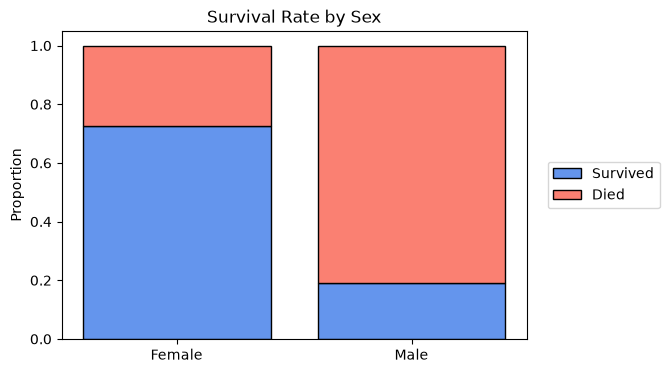

In [2]:

female_survival_rate = np.sum((df.sex == 'female') & (df.Survived == "1")) / np.sum(df.sex == 'female')

male_survival_rate = np.sum((df.sex == 'male') & (df.Survived == "1")) / np.sum(df.sex == 'male')
sex_survival_rates = np.array([female_survival_rate, male_survival_rate])
sex_death_rates = 1 - sex_survival_rates

plt.figure(figsize=[6,4])
plt.bar(['Female', 'Male'], sex_survival_rates, label='Survived',
        color='cornflowerblue', edgecolor='k')
plt.bar(['Female', 'Male'], sex_death_rates, label='Died',
        bottom=sex_survival_rates, color='Salmon', edgecolor='k')
plt.legend(loc="center left", bbox_to_anchor=(1.03,0.5))
plt.ylabel('Proportion')
plt.title('Survival Rate by Sex')
plt.show()

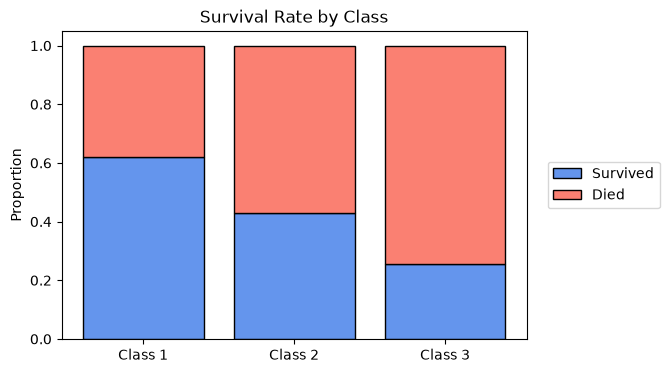

In [3]:
class1_survival_rate = np.sum((df.pclass == 1) & (df.Survived == "1")) / np.sum(df.pclass == 1)
class2_survival_rate = np.sum((df.pclass == 2) & (df.Survived == "1")) / np.sum(df.pclass == 2)
class3_survival_rate = np.sum((df.pclass == 3) & (df.Survived == "1")) / np.sum(df.pclass == 3)
class_survival_rates = np.array([class1_survival_rate, class2_survival_rate, class3_survival_rate])
class_death_rates = 1 - class_survival_rates

plt.figure(figsize=[6,4])
plt.bar(['Class 1', 'Class 2', 'Class 3'], class_survival_rates, label='Survived',
        color='cornflowerblue', edgecolor='k')
plt.bar(['Class 1', 'Class 2', 'Class 3'], class_death_rates, label='Died',
        bottom=class_survival_rates, color='Salmon', edgecolor='k')
plt.legend(loc="center left", bbox_to_anchor=(1.03,0.5))
plt.ylabel('Proportion')
plt.title('Survival Rate by Class')
plt.show()

While one could plot Survival by age, in the code below, I just set an age cut-off for what is considered a child and did a binary comparison. Play around with the age cut-off parameter and see what age cut-off produces the sharpest split in survival rates. Try 2, 5, 10 and 18.

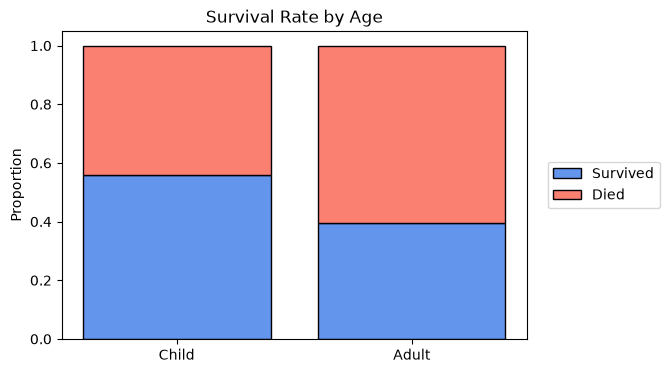

In [10]:
cutoff = 12 #age cut off for what is considered a child
c_survival_rate = np.sum((df.age < cutoff) & (df.Survived == "1")) / np.sum(df.age < cutoff)

adult_survival_rate = np.sum((df.age >= cutoff) & (df.Survived == "1")) / np.sum(df.age > cutoff)
age_survival_rates = np.array([c_survival_rate,adult_survival_rate])
age_death_rates = 1 - age_survival_rates

plt.figure(figsize=[6,4])
plt.bar(['Child', 'Adult'], age_survival_rates, label='Survived',
        color='cornflowerblue', edgecolor='k')
plt.bar(['Child', 'Adult'], age_death_rates, label='Died',
        bottom=age_survival_rates, color='Salmon', edgecolor='k')
plt.legend(loc="center left", bbox_to_anchor=(1.03,0.5))
plt.ylabel('Proportion')
plt.title('Survival Rate by Age')
plt.show()

We will now work on predicting whether a passenger survived or not. To start, we split off the numerical features and do a one-hot encoding on the categorical ones (sex and pclass)

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#subset the numerical and categorical separately
Xnum = df[['age']].values
Xcat = df[['sex','pclass']].values.astype('str')
y = df['Survived'].values

encoder = OneHotEncoder()
Xenc = encoder.fit_transform(Xcat).toarray()

X = np.hstack([Xnum, Xenc])

Do the test-train split

In [12]:
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size = 0.3, random_state=1, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size = 0.5, random_state=1, stratify=y_hold)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(916, 6)
(196, 6)
(197, 6)


Create LOGISTIC regression model
**Warning: this will throw an error; we'll fix it in the next step**

In [13]:
logreg_model = LogisticRegression(solver='lbfgs', penalty=None)
logreg_model.fit(X_train, y_train)

print('Training Accuracy:  ', round(logreg_model.score(X_train, y_train),4))
print('Validation Accuracy:', round(logreg_model.score(X_valid, y_valid),4))

c:\Users\munas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

I get an error because there are missing values in the age feature. We could drop the rows with missing values, but since sex and pclass might contain valuable info, it would make more sense to keep them.

We will solve this by 'imputing' missing values - in particular, missing ages will be set equal to the median age of the training set

In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_valid = imputer.transform(X_valid) #note that we DON'T use fit_transform because we want to re-use the median from the X_train set for consistency
X_test = imputer.transform(X_test)

logreg_model = LogisticRegression(solver='lbfgs', penalty=None)
logreg_model.fit(X_train, y_train)
print('Training Accuracy:  ', round(logreg_model.score(X_train, y_train),4))
print('Validation Accuracy:', round(logreg_model.score(X_valid, y_valid),4))

Training Accuracy:   0.7871
Validation Accuracy: 0.7908


c:\Users\munas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Before moving on, let's notice that this is a dumb way to produce output. We're going to be outputting the rounded scores for a lot of different models, so it would make sense to use a function call instead of typing out the 'round' function every time. Write a function called print_score that takes in a string that describes the metric ("Training Accuracy") and the score, rounds the score to 4 decimals, and prints the desired statement. The function should not return anything.

Sample function call:

print_score("Training Accuracy", logreg_model.score(X_train, y_train))

In [ ]:
#your function definition here
def print_score(score_label, score):
    print(round(score,4), score_label)

Now on to Decision Tree. Let's produce a bunch of trees with different max depths so we can see how to maximize accuracy.

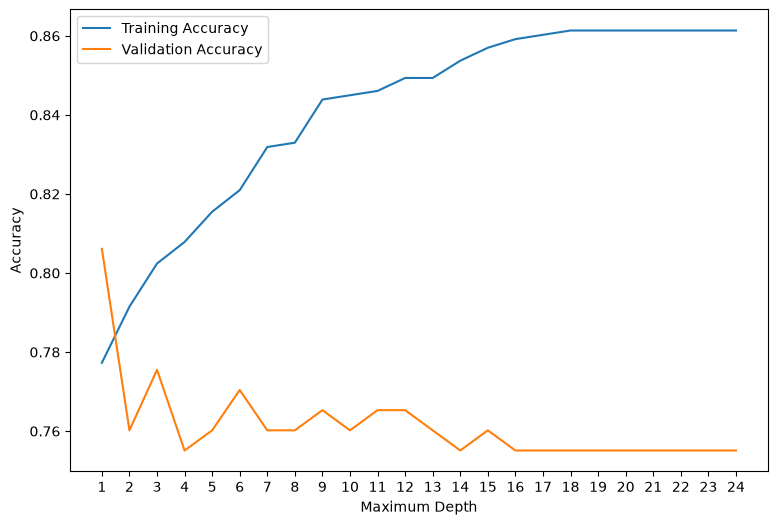

In [16]:
tr_acc = []
va_acc = []

depth_list = range(1,25)

for d in depth_list:
    temp_mod = DecisionTreeClassifier(max_depth=d, random_state=1)
    temp_mod.fit(X_train, y_train)
    tr_acc.append(temp_mod.score(X_train, y_train))
    va_acc.append(temp_mod.score(X_valid, y_valid))

plt.figure(figsize=([9, 6]))
plt.plot(depth_list, tr_acc, label='Training Accuracy')
plt.plot(depth_list, va_acc, label='Validation Accuracy')
plt.xlabel('Maximum Depth')
plt.ylabel('Accuracy')
plt.xticks(depth_list)
plt.legend()
plt.show()

Do the predictions get better with deeper trees? Which line here is the important one?

In [17]:
# automate the selection of the best value
best_md = depth_list[np.argmax(va_acc)]
print('Optimal Value of max_depth:', best_md)

Optimal Value of max_depth: 1



 Now that we know the desired max_depth of the trees, we are going to use a *Random Forest* approach. Internally, the random forest model will take the training data and vary its tree construction - using different features, different slices of the dataset - and it outputs a tree that uses the 'best' choice of features (majority vote). This method can reduce overfitting in some cases. The process will have some randomness.

In [22]:
# I'm repeating some previous code to go back to point before we imputed values; the Decision Tree Classifier will handle missing values its own way
y = df['Survived'].values #
X = np.hstack([Xnum, Xenc])
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size = 0.3, random_state=1, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size = 0.5, random_state=1, stratify=y_hold)
tr_acc = []
va_acc = []

depth_list = range(1,25)

for d in depth_list:
    temp_mod = DecisionTreeClassifier(max_depth=d, random_state=1)
    temp_mod.fit(X_train, y_train)
    tr_acc.append(temp_mod.score(X_train, y_train))
    va_acc.append(temp_mod.score(X_valid, y_valid))
best_md = depth_list[np.argmax(va_acc)]
forest_mod = RandomForestClassifier(n_estimators=500, max_depth=best_md, random_state=1)

forest_mod.fit(X_train, y_train)
# YOUR CODE HERE - find out the train and test accuracies by calling your print_score function on forest_mod.score(X_train, y_train) etc
def print_score(score_label, score):
    print(round(score,4), score_label)

print_score('Training Accuracy:  ', forest_mod.score(X_train, y_train))
print_score('Validation Accuracy:  ', forest_mod.score(X_valid, y_valid))
print_score('Test Accuracy:  ', forest_mod.score(X_test, y_test))

0.7773 Training Accuracy:  
0.8061 Validation Accuracy:  
0.7665 Test Accuracy:  


I found that it only wanted a single variable to split on to get the best accuracy on the validation set. Let's see which variable it is choosing.

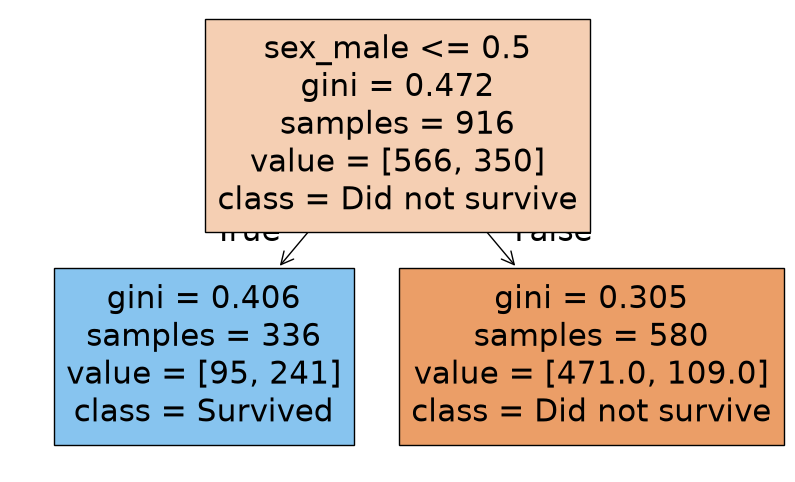

In [25]:
from sklearn.tree import plot_tree
# build a tree with the best possible max_depth (if you got a different max_depth, change it)
tree_model = DecisionTreeClassifier(max_depth=1, random_state=1)
tree_model.fit(X_train, y_train)

#plot the tree
plt.figure(figsize=(10, 6))
feature_names = ['age'] + list(encoder.get_feature_names_out(['sex', 'pclass']))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Did not survive', 'Survived'],
    filled=True
)

plt.show()

 **Type your answers below:**
 1. Which variable is the single most important variable? sex
2. What happens to the accuracy on the validation set as you add more depth? it gets worse
3. What happens to the accuracy on the **training** set as you add more depth? as the depth increases the validation accuracy gets worse while the training accuracy gets better.
4. Do we want to maximize validation accuracy, or training accuracy? Why? validation accuracy, because it acts as a test to see if the training was effective (not overfitted)

Build a deeper tree (with a depth of 3) and compare the splits.



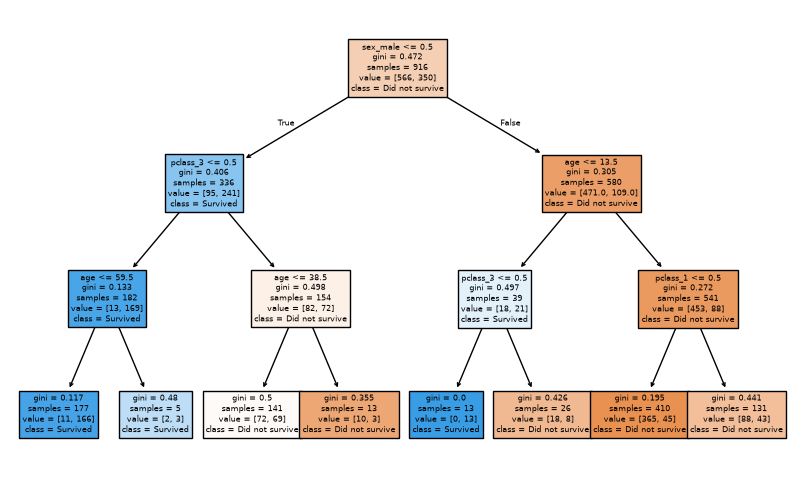

In [26]:
# YOUR CODE HERE

from sklearn.tree import plot_tree
# build a tree with the best possible max_depth (if you got a different max_depth, change it)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=1)
tree_model.fit(X_train, y_train)

#plot the tree
plt.figure(figsize=(10, 6))
feature_names = ['age'] + list(encoder.get_feature_names_out(['sex', 'pclass']))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Did not survive', 'Survived'],
    filled=True
)

plt.show()

Here's my tree 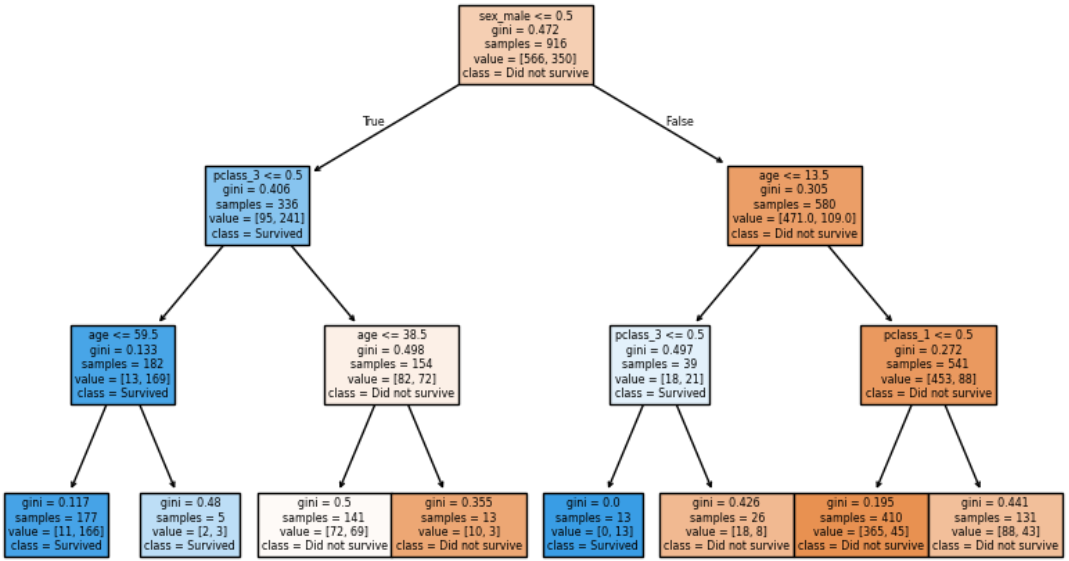

My tree might be different from yours due to the randomness in the test-train splitting. Please type in your answers to these questions:

Looking at the **Gini coefficients** in MY tree,
1.  which split produces a pure partition? the third split on pclass_3 has a gini coefficient of 0
2. Which group of passengers in the training data has a 100% chance of surviving? (Note that this may not generalize beyond the training data.) males who are under 13.5 years old who are not in 3rd class
